# Нейросеть для предсказания калорийности блюд

Регрессионная задача, предсказать калорийность блюда по предоставленному фото и ингредиентам.

## Целевая метрика
Модель будет считаться готовой к интеграции в продукт при точности оценки MAE < 50 (MAE — Mean Absolute Error) на тестовой выборке. 

## Этап 1. Исследовательский анализ (EDA)

**1. Загрузим набор данных, изучим то, с чем предстоит работать:**

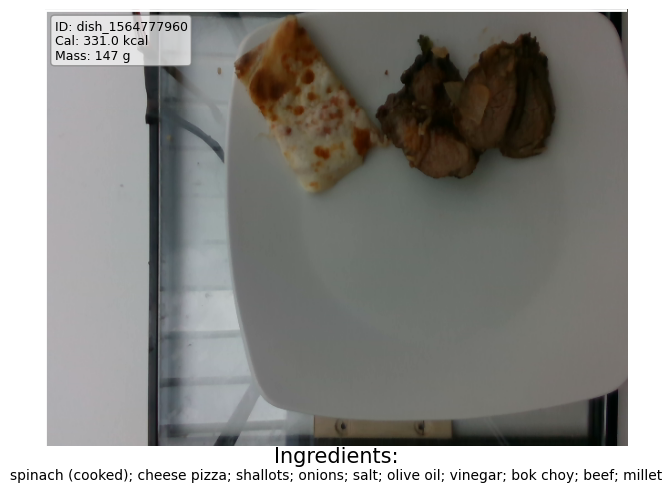

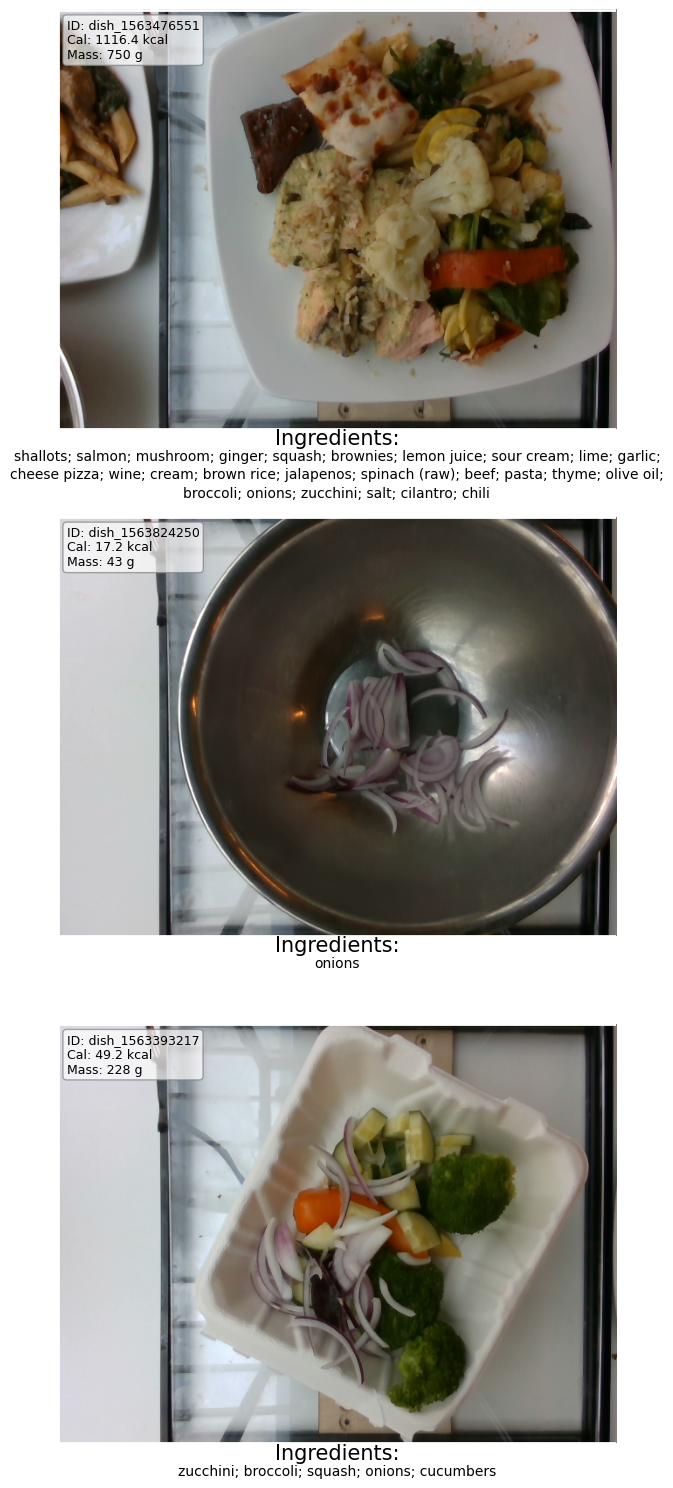

In [1]:
from DeepPlate import MultimodalDataset
from experiment_config import Config

config = Config()
train_ds = MultimodalDataset(config, split="train", transform=None)

# Показать один пример
train_ds.show_samples(42)

# Показать несколько
train_ds.show_samples([10, 20, 30], figsize_per_sample=(7, 5))

**2. Проанализируем, как подойти к задаче:**

 1) Задачу регресси будем решать с использованием дообучения мультимодальной модели, построенной на CrossAttention. В первую очередь, определимся, какие будем использовать претренированные модели на старте:

- Для изображений: "efficientnet-b3",

- Для ингредиентов: "bert-base-uncased",

- Для данных массы блюда - попробуем обучить простой MLP, должен быстро схватить взаимосвязи.

Попробуем применить следующую стратегию разморозки предобученных слоев:

- Сначала заморозить всё, обучить только  регрессионную и "массовую" головы 5 эпох,

- Разморозить последние слои (как в конфиге) еще на 15 эпох обучения.

- Полная разморозка с маленьким LR (1e-6) для тонкой настройки 10 эпох

2) Для агументации:

- Мы можем позволить себе небольшой дрифт по цветам, т.к. цвет продуктов на блюде может иметь высокую ценность. Остальные аугментации - случайный разворот, повороты, небольшой шум.

- Массу можно аугментировать достаточно смело. Например - подавать с некоторой случайностью массу чуть больше или чуть меньше. В задаче взвешивания тела всегда есть инструментальная погрешность, влияние количества воды в продукте, разные веса тарелок, - если взвешивание происходит с ними или без, поэтому, мне кажется, что нужно лишь сохранить порядок величины:
  
    - +-5% от исходной массы для небольших масс - до 200 гр,

    - и около +- 10% для блюд большей массы.

3) При обучении будем ориентироваться на MAE, считать loss через HuberLoss, выводить коэффициент детерминации ($R^2$).  


Подберем оптимальную длину паддинга

Total samples: 3262
Min length: 3
Max length: 103
Mean length: 22.6
Median length: 14.0
95th percentile: 62.0
99th percentile: 79.4


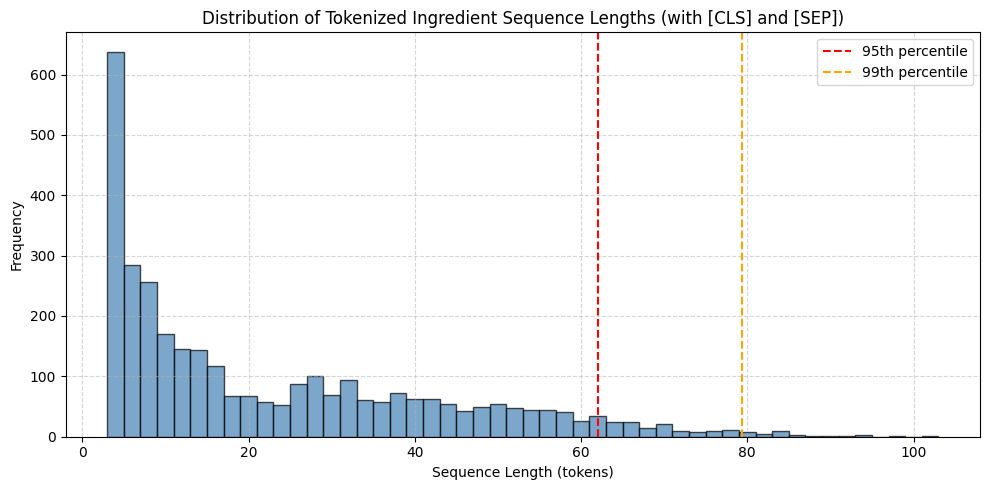

In [ ]:
import pandas as pd
from pathlib import Path
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import numpy as np

# --- Paths ---
data_root = Path("data")
dish_csv = data_root / "dish.csv"
ingredients_csv = data_root / "ingredients.csv"

# --- Load data ---
dish_df = pd.read_csv(dish_csv)
ingredients_df = pd.read_csv(ingredients_csv)

# Build ingredient ID → name map
ingredients_df["id_str"] = "ingr_" + ingredients_df["id"].astype(str).str.zfill(10)
ingr_id_to_name = dict(zip(ingredients_df["id_str"], ingredients_df["ingr"]))

def parse_ingredients_text(ingr_ids_str: str) -> str:
    if not isinstance(ingr_ids_str, str) or ingr_ids_str == "":
        return ""
    ingr_ids = ingr_ids_str.split(";")
    names = [ingr_id_to_name.get(ingr_id, "") for ingr_id in ingr_ids]
    names = [name for name in names if name]
    return "; ".join(names)

# --- Convert all ingredient lists to text ---
ingredient_texts = dish_df["ingredients"].apply(parse_ingredients_text)

# --- Tokenize WITHOUT padding/truncation ---
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
lengths = []

for text in ingredient_texts:
    tokens = tokenizer.encode(text, add_special_tokens=True)  # [CLS] ... [SEP]
    lengths.append(len(tokens))

lengths = np.array(lengths)

# --- Statistics ---
print(f"Total samples: {len(lengths)}")
print(f"Min length: {lengths.min()}")
print(f"Max length: {lengths.max()}")
print(f"Mean length: {lengths.mean():.1f}")
print(f"Median length: {np.median(lengths):.1f}")
print(f"95th percentile: {np.percentile(lengths, 95):.1f}")
print(f"99th percentile: {np.percentile(lengths, 99):.1f}")

# --- Plot ---
plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=50, color="steelblue", edgecolor="black", alpha=0.7)
plt.axvline(np.percentile(lengths, 95), color="red", linestyle="--", label="95th percentile")
plt.axvline(np.percentile(lengths, 99), color="orange", linestyle="--", label="99th percentile")
plt.title("Distribution of Tokenized Ingredient Sequence Lengths (with [CLS] and [SEP])")
plt.xlabel("Sequence Length (tokens)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Начну с установки Config.MAX_LENGTH = 96, думаю, это более чем оптимальный выбор.

Взглянем на выходящий элемент:

In [ ]:
train_ds[10]

{'image': <PIL.Image.Image image mode=RGB size=640x480>,
 'input_ids': tensor([  101,  4618, 12868,  1025, 11840,  1025, 18565,  1025, 14580,  1025,
         18794,  1025,  2829,  3111,  1025, 14380, 10869,  1025, 14768,  6949,
          1025, 14123,  1025, 20548,  1025,  8808, 10733,  1025,  4511,  1025,
          6949,  1025,  2829,  5785,  1025, 14855,  2721, 11837,  2891,  1025,
          6714,  6776,  1006,  6315,  1007,  1025, 12486,  1025, 24857,  1025,
         15177,  4168,  1025,  9724,  3514,  1025, 22953, 21408,  3669,  1025,
         24444,  1025, 16950, 25955,  3490,  1025,  5474,  1025, 25022,  5802,
         13181,  1025, 20238,   102,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,    

Осталось подобрать аугментации:

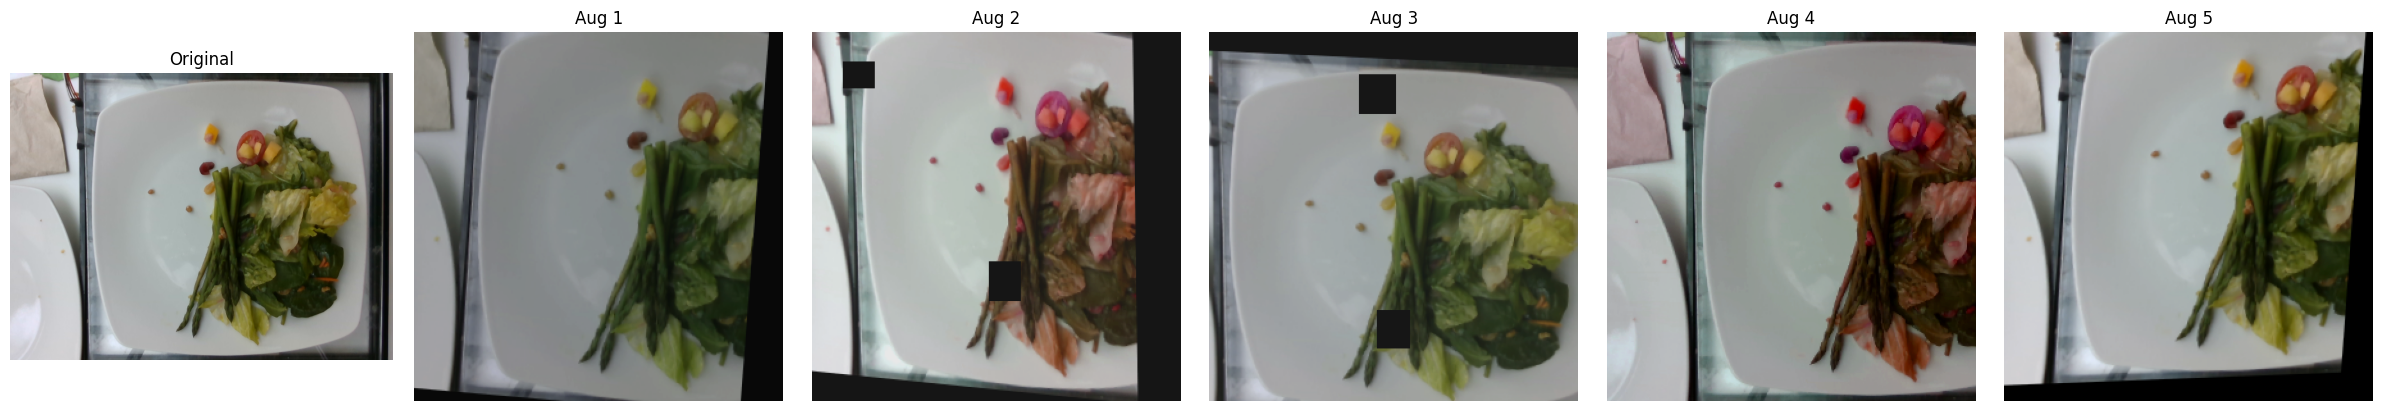

In [ ]:
import os
from pathlib import Path
import pandas as pd
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

from DeepPlate import Config
from DeepPlate import get_multimodal_transforms


# --- 1. Загрузим Config и получим одно изображение ---
config = Config()

# Загрузим dish.csv и возьмём первый трейновый пример
dish_df = pd.read_csv(config.dish_csv_path)
train_df = dish_df[dish_df["split"] == "train"].reset_index(drop=True)

# Возьмём блюдо
sample_row = train_df.iloc[3]
dish_id = sample_row["dish_id"]
image_path = config.images_dir / str(dish_id) / "rgb.png"

# Загрузим как PIL → numpy
original_pil = Image.open(image_path).convert("RGB")
original_np = np.array(original_pil)

# --- 2. Получим train-трансформы ---
train_transforms = get_multimodal_transforms(config, ds_type="train")

# --- 3. Применим аугментации несколько раз ---
n_aug = 5
augmented_images = []
for i in range(n_aug):
    # albumentations ожидает numpy array с типом uint8
    transformed = train_transforms(image=original_np.copy())
    aug_tensor = transformed["image"]  # это уже torch.Tensor, нормализованный

    # Для визуализации нужно ОБРАТНО денормализовать!
    mean = np.array(train_transforms.transforms[-2].mean)  # A.Normalize mean
    std = np.array(train_transforms.transforms[-2].std)   # A.Normalize std

    # Обратное преобразование: (x_norm * std) + mean, затем в [0, 255]
    aug_np = aug_tensor.permute(1, 2, 0).numpy()
    aug_denorm = (aug_np * std) + mean
    aug_denorm = np.clip(aug_denorm, 0, 1)  # clamp to [0, 1]
    aug_denorm_uint8 = (aug_denorm * 255).astype(np.uint8)

    augmented_images.append(aug_denorm_uint8)

# --- 4. Визуализация ---
fig, axes = plt.subplots(1, n_aug + 1, figsize=(4 * (n_aug + 1), 4))

# Оригинал
axes[0].imshow(original_pil)
axes[0].set_title("Original", fontsize=12)
axes[0].axis("off")

# Аугментации
for i, aug_img in enumerate(augmented_images):
    axes[i + 1].imshow(aug_img)
    axes[i + 1].set_title(f"Aug {i+1}", fontsize=12)
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

Такой набор аугментаций должен повысить стабильность модели при инференсе, и создать достаточный набор информации для регрессии.

Подберем аугментации для массы. Для этого оценим распределение массы для датасета

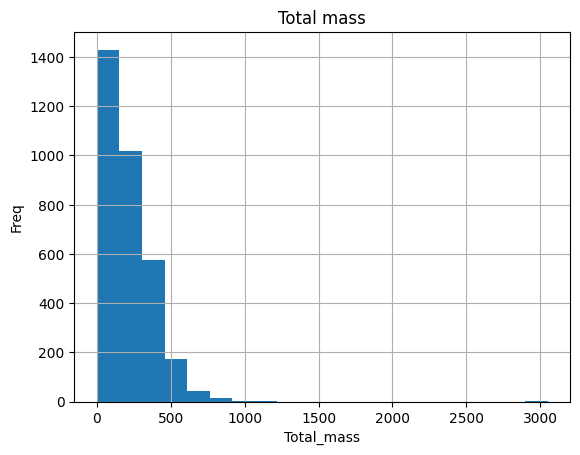

In [ ]:
import matplotlib.pyplot as plt

dish_df = pd.read_csv(config.dish_csv_path)
dish_df['total_mass'].hist(bins=20)
plt.xlabel("Total_mass")
plt.ylabel("Freq")
plt.title("Total mass")
plt.show()

In [ ]:
print(f"Mean mass: {dish_df['total_mass'].mean()} \nStd mass: {dish_df['total_mass'].std()}")

Mean mass: 214.98007357449418 
Std mass: 161.4974275523783


Как видно, есть выбросы, который влияют на отклонение по массе в нашем датасете и плохо скажется на регрессионной задаче. Найдем эти элементы и их количество.

In [ ]:
dish_df[dish_df["total_mass"] > 6*dish_df['total_mass'].mean()]

,dish_id,total_calories,total_mass,ingredients,split
1518,dish_1560974769,3943.325195,3051.0,ingr_0000000036;ingr_0000000251;ingr_000000004...,train


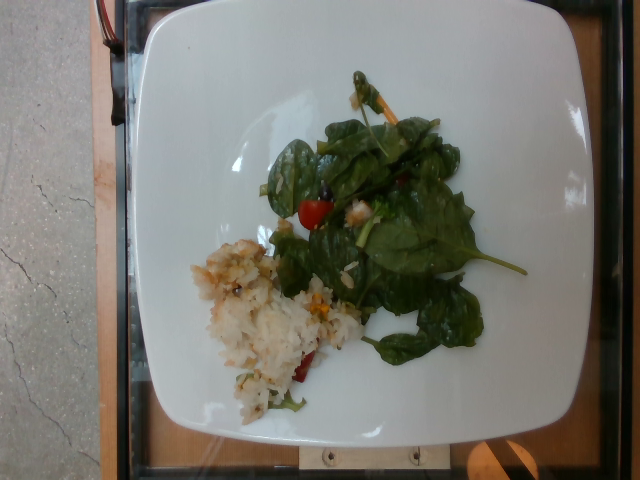

In [30]:
from IPython.display import Image
path_to_image = "data/images/dish_1560974769/rgb.png"
Image(path_to_image)

Получается всего один элемент. Думаю, его можно просто десятикратно уменьшить т.к. это будет больше похоже на правду.

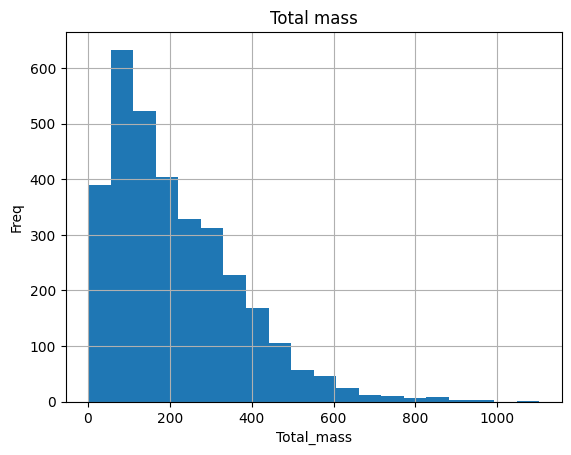

In [ ]:
dish_df = pd.read_csv(config.dish_csv_path)
dish_df['total_mass'].hist(bins=20)
plt.xlabel("Total_mass")
plt.ylabel("Freq")
plt.title("Total mass")
plt.show()

In [ ]:
print(f"Mean mass: {dish_df['total_mass'].mean()} \nStd mass: {dish_df['total_mass'].std()} \nMin mass: {dish_df['total_mass'].min()}\nMax mass: {dish_df['total_mass'].max()} ")

Mean mass: 214.11039558417664 
Std mass: 153.6928179441193 
Min mass: 1.0
Max mass: 1102.0 


Проанализирую другие данные, которых еще больше - есть подозрение на блюда малой массы:

In [3]:
from DeepPlate import MultimodalDataset, Config

def show_samples_with_mass_below(config, max_mass: float = 10.0, max_samples: int = 10) -> None:
    """
    Визуализирует до `max_samples` примеров из датасета,
    у которых total_mass < `max_mass` грамм.
    
    Args:
        config (Config): конфиг проекта.
        max_mass (float): порог массы в граммах (по умолчанию 10).
        max_samples (int): максимальное количество примеров для отображения.
    """
    # Загружаем весь датасет без трансформаций для EDA
    dataset = MultimodalDataset(config, split="train", transform=None)
    
    # Ищем индексы блюд с массой < max_mass
    indices = []
    for i in range(len(dataset.dish_df)):
        mass = dataset.dish_df.iloc[i]["total_mass"]
        if mass < max_mass:
            indices.append(i)
            if len(indices) >= max_samples:
                break
    
    if not indices:
        print(f"Нет блюд с массой менее {max_mass} грамм.")
        return
    
    print(f"Найдено {len(indices)} блюд(а) с массой < {max_mass} г. Отображение...")
    dataset.show_samples(indices, figsize_per_sample=(8, 5))

Найдено 10 блюд(а) с массой < 20 г. Отображение...


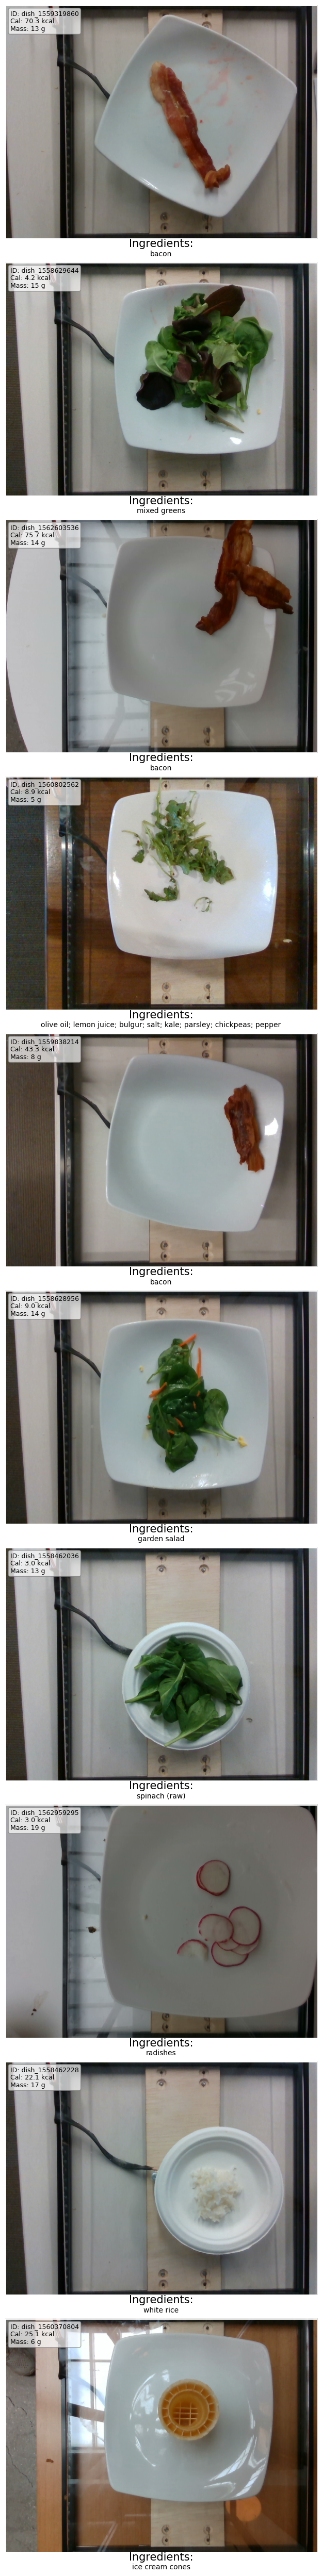

In [4]:
show_samples_with_mass_below(config, 20)

## Этап 2. Реализуем пайплайн обучения.

Универсальный конфиг модели представлен в валидируемом файле: [experiment_config.py](./experiment_config.py)


In [1]:
from DeepPlate import Config

config = Config()

1) Реализуем загрузчики данных:

In [2]:
import torch.nn as nn
from torch.utils.data import DataLoader


from DeepPlate import (
    get_multimodal_transforms, 
    MultimodalDataset, 
    multimodal_collate_fn)

train_transforms = get_multimodal_transforms(config, "train")
val_transforms = get_multimodal_transforms(config, "val")
train_dataset = MultimodalDataset(config, split="train", transform=train_transforms)
val_dataset = MultimodalDataset(config, split="test", transform=val_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    collate_fn=multimodal_collate_fn,  # no args!
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    collate_fn=multimodal_collate_fn,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

Поместим эти решения в общую функцию трейна в модуле: [train_multimodal_model.py](src/train_multimodal_model.py)

## Этап 3 Обучение модели.

Выполним обучение на первые 15 эпох, оценим сходимость модели, и получающееся качество:

Сейчас экспериментируем - разморозим только эти слои:

- TEXT_MODEL_UNFREEZE: str = "encoder.layer.11|pooler"

- IMAGE_MODEL_UNFREEZE: str = "blocks.6"

In [2]:

from DeepPlate import CalorieRegressionModel
from DeepPlate import set_requires_grad
from DeepPlate import train_multimodal_model


# === 1. Создаём модель ===
model = CalorieRegressionModel(config)

# === 2. ПРИМЕНЯЕМ СТРАТЕГИЮ РАЗМОРОЗКИ (этап 1, 2 или 3) ===
set_requires_grad(model.text_model, unfreeze_pattern=config.TEXT_MODEL_UNFREEZE)
set_requires_grad(model.image_model, unfreeze_pattern=config.IMAGE_MODEL_UNFREEZE)

# === 3. Запускаем обучение на 15 эпох ===
train_multimodal_model(model, config)

Training on device: cuda
Starting training...


Epoch 1/15 | Train Loss: 233.7617, MAE: 235.05, R²: -1.1240 | Val Loss: 223.3929, MAE: 224.68, R²: -1.0833
New best model saved: models/best_model.pth (Val MAE: 224.68)


Epoch 2/15 | Train Loss: 214.3300, MAE: 213.87, R²: -0.8737 | Val Loss: 204.3034, MAE: 205.60, R²: -0.8230
New best model saved: models/best_model.pth (Val MAE: 205.60)


Epoch 3/15 | Train Loss: 193.5833, MAE: 195.83, R²: -0.6455 | Val Loss: 186.2336, MAE: 187.48, R²: -0.5965
New best model saved: models/best_model.pth (Val MAE: 187.48)


Epoch 4/15 | Train Loss: 176.7575, MAE: 178.16, R²: -0.4315 | Val Loss: 168.6470, MAE: 169.85, R²: -0.3630
New best model saved: models/best_model.pth (Val MAE: 169.85)


...

Epoch 11/15 | Train Loss: 103.0286, MAE: 104.42, R²: 0.3986 | Val Loss: 84.9151, MAE: 85.78, R²: 0.5507
New best model saved: models/best_model.pth (Val MAE: 85.78)


Epoch 12/15 | Train Loss: 102.8053, MAE: 100.92, R²: 0.4363 | Val Loss: 79.2909, MAE: 80.17, R²: 0.5915
New best model saved: models/best_model.pth (Val MAE: 80.17)


Epoch 13/15 | Train Loss: 99.2301, MAE: 99.24, R²: 0.4563 | Val Loss: 77.0458, MAE: 77.83, R²: 0.6181
New best model saved: models/best_model.pth (Val MAE: 77.83)


Epoch 14/15 | Train Loss: 98.5287, MAE: 96.65, R²: 0.4811 | Val Loss: 74.3624, MAE: 75.17, R²: 0.6452
New best model saved: models/best_model.pth (Val MAE: 75.17)


Epoch 15/15 | Train Loss: 94.8390, MAE: 94.98, R²: 0.4957 | Val Loss: 72.5445, MAE: 73.31, R²: 0.6649
New best model saved: models/best_model.pth (Val MAE: 73.31)


Сходимость последние 3 эпохи медленная, но есть, думаю, следует дообучиться еще на 15 эпохах. Следов переобучения не наблюдаю.

In [3]:
# === 4. Запускаем обучение еще на 15 эпох ===
train_multimodal_model(model, config)

Training on device: cuda
Starting training...


Epoch 1/15 | Train Loss: 94.2641, MAE: 95.12, R²: 0.5004 | Val Loss: 72.1094, MAE: 72.89, R²: 0.6681
New best model saved: models/best_model.pth (Val MAE: 72.89)


Epoch 2/15 | Train Loss: 93.4593, MAE: 93.43, R²: 0.5153 | Val Loss: 67.5004, MAE: 68.23, R²: 0.7101
New best model saved: models/best_model.pth (Val MAE: 68.23)


Epoch 3/15 | Train Loss: 92.6859, MAE: 93.63, R²: 0.5234 | Val Loss: 69.0777, MAE: 69.85, R²: 0.6947


Epoch 4/15 | Train Loss: 91.2423, MAE: 92.09, R²: 0.5273 | Val Loss: 68.4078, MAE: 69.19, R²: 0.7160


...

Epoch 11/15 | Train Loss: 87.7427, MAE: 88.41, R²: 0.5568 | Val Loss: 65.6885, MAE: 66.44, R²: 0.7512


Epoch 12/15 | Train Loss: 89.3826, MAE: 87.93, R²: 0.5565 | Val Loss: 65.7896, MAE: 66.57, R²: 0.7403


Epoch 13/15 | Train Loss: 87.0071, MAE: 87.33, R²: 0.5621 | Val Loss: 67.5284, MAE: 68.33, R²: 0.7274


Epoch 14/15 | Train Loss: 86.9704, MAE: 85.04, R²: 0.5712 | Val Loss: 63.0842, MAE: 63.82, R²: 0.7603
New best model saved: models/best_model.pth (Val MAE: 63.82)


Epoch 15/15 | Train Loss: 84.0946, MAE: 84.36, R²: 0.5800 | Val Loss: 62.8304, MAE: 63.57, R²: 0.7676
New best model saved: models/best_model.pth (Val MAE: 63.57)


Видно, что модель стала очень медленно сходиться. Переобучения пока не видно, наоборот, кривые трейна и валидации еще не сблизились. Возможно, требуется еще 40 эпох для схождения. Запустим обучение еще на 40 эпох.

In [4]:
config.EPOCHS = 40

print(config.EPOCHS)

40


In [5]:
# === 5. Запускаем обучение еще на 40 эпох ===
train_multimodal_model(model, config)

Training on device: cuda
Starting training...


Epoch 1/40 | Train Loss: 85.2735, MAE: 86.27, R²: 0.5658 | Val Loss: 62.8022, MAE: 63.54, R²: 0.7631
New best model saved: models/best_model.pth (Val MAE: 63.54)


Epoch 2/40 | Train Loss: 85.2416, MAE: 85.62, R²: 0.5663 | Val Loss: 61.9427, MAE: 62.61, R²: 0.7794
New best model saved: models/best_model.pth (Val MAE: 62.61)


Epoch 3/40 | Train Loss: 85.2688, MAE: 86.28, R²: 0.5710 | Val Loss: 62.8128, MAE: 63.56, R²: 0.7633


Epoch 4/40 | Train Loss: 84.0528, MAE: 84.87, R²: 0.5753 | Val Loss: 63.5778, MAE: 64.29, R²: 0.7682


...

Epoch 36/40 | Train Loss: 83.8686, MAE: 84.09, R²: 0.5957 | Val Loss: 57.7660, MAE: 58.47, R²: 0.8102


Epoch 37/40 | Train Loss: 83.5004, MAE: 84.28, R²: 0.5846 | Val Loss: 57.4591, MAE: 58.19, R²: 0.8133


Epoch 38/40 | Train Loss: 84.2543, MAE: 85.18, R²: 0.5858 | Val Loss: 57.2943, MAE: 57.95, R²: 0.8180


Epoch 39/40 | Train Loss: 84.5079, MAE: 84.30, R²: 0.5908 | Val Loss: 57.7387, MAE: 58.34, R²: 0.8167


Epoch 40/40 | Train Loss: 83.6259, MAE: 83.78, R²: 0.5909 | Val Loss: 57.4597, MAE: 58.13, R²: 0.8141


Попробуем загрузить лучшую модель, - MAE - 56.13. Уменьшим темп обучения (возможно мы прыгаем вокруг входа в минимум), и попробуем дообучить её еще 20 эпох.

In [1]:
import torch

from DeepPlate import (
    Config,
    CalorieRegressionModel,
    set_requires_grad,
    train_multimodal_model
)
# 1. Загрузим лучшую модель
config = Config(EPOCHS=20)
model = CalorieRegressionModel(config)
model.load_state_dict(torch.load("models/best_model.pth"))

# 2. Применим разморозку
set_requires_grad(model.text_model, config.TEXT_MODEL_UNFREEZE)
set_requires_grad(model.image_model, config.IMAGE_MODEL_UNFREEZE)

# 3. Уменьшим LR
config.TEXT_LR = 2e-6
config.IMAGE_LR = 1e-5
config.FUSION_LR = 2e-5
config.HEAD_LR = 1e-4

In [2]:
# === 6. Запускаем обучение еще на 20 эпох ===
train_multimodal_model(model, config)

Training on device: cuda
Starting training...


Epoch 1/20 | Train Loss: 78.4353, MAE: 79.37, R²: 0.6113 | Val Loss: 57.7366, MAE: 58.43, R²: 0.8123
New best model saved: models/best_model.pth (Val MAE: 58.43)


Epoch 2/20 | Train Loss: 78.5624, MAE: 78.93, R²: 0.6138 | Val Loss: 56.7583, MAE: 57.44, R²: 0.8258
New best model saved: models/best_model.pth (Val MAE: 57.44)


Epoch 3/20 | Train Loss: 79.2890, MAE: 80.40, R²: 0.6102 | Val Loss: 56.3263, MAE: 57.03, R²: 0.8226
New best model saved: models/best_model.pth (Val MAE: 57.03)


Epoch 4/20 | Train Loss: 76.4508, MAE: 77.25, R²: 0.6217 | Val Loss: 57.3347, MAE: 58.01, R²: 0.8220


...

Epoch 16/20 | Train Loss: 77.1468, MAE: 78.20, R²: 0.6121 | Val Loss: 58.7006, MAE: 59.33, R²: 0.8109


Epoch 17/20 | Train Loss: 76.5260, MAE: 77.25, R²: 0.6170 | Val Loss: 57.2296, MAE: 57.88, R²: 0.8184


Epoch 18/20 | Train Loss: 77.4556, MAE: 78.44, R²: 0.6165 | Val Loss: 58.7997, MAE: 59.44, R²: 0.8118


Epoch 19/20 | Train Loss: 76.4093, MAE: 77.55, R²: 0.6147 | Val Loss: 58.0737, MAE: 58.71, R²: 0.8147


Epoch 20/20 | Train Loss: 77.0720, MAE: 77.99, R²: 0.6241 | Val Loss: 56.5814, MAE: 57.22, R²: 0.8252


Видно, модель сходится довольно плохо, и на данной конфигурации удалось достичь качества 

"New best model saved: models/best_model.pth (Val MAE: 57.03)"

Сохраню эту модель. 

Вот конфиги, на которых удалось достичь этой точности.

```py
# --- Model backbones ---
    TEXT_MODEL_NAME: str = "bert-base-uncased"
    IMAGE_MODEL_NAME: str = "efficientnet_b3"
    
    IMAGE_SIZE: Tuple[int, int] = (224, 224)  # стандарт для ResNet/EfficientNet
    IMAGE_MEAN: List[float] = [0.485, 0.456, 0.406]  # ImageNet stats
    IMAGE_STD: List[float] = [0.229, 0.224, 0.225]

    # --- Tokenization ---
    MAX_LENGTH: int = 96

    # --- Fine-tuning strategy ---
    TEXT_MODEL_UNFREEZE: str = "encoder.layer.11|pooler"
    IMAGE_MODEL_UNFREEZE: str = "blocks.6"
    EMB_DIM: int = 256
    
    # --- MLP head ---
    MLP_HIDDEN_DIM: int = 128
    MLP_OUT_DIM: int = 256
    MLP_DROPOUT: float = 0.1
    
    # --- Regression head  ---
    HIDDEN_DIM: int = 512  # размер скрытого слоя перед выходом
    DROPOUT: float = 0.3  # для регуляризации регрессии

    # --- Training hyperparameters ---
    BATCH_SIZE: int = Field(default=32, ge=1) # можно 16 если мало памяти
    EPOCHS: int = Field(default=15, ge=1)
    SEED: int = 2025
    NUM_WORKERS: int = 4
    

    
    # --- Validation ---
    VAL_SPLIT: float = 0.2
    EARLY_STOPPING_PATIENCE: int = 10  # для регрессии

    # --- Per-component learning rates ---
    TEXT_LR: float = 1e-5
    IMAGE_LR: float = 5e-5
    FUSION_LR: float = 1e-4  # for cross-attention / fusion head
    HEAD_LR: float = 5e-4    # for final regression head (if separate)

    # После 70 эпохи:
    config.TEXT_LR = 2e-6
    config.IMAGE_LR = 1e-5
    config.FUSION_LR = 2e-5
    config.HEAD_LR = 1e-4

```

Предприму попытку обучить модель с нуля, разморозив 2 последних слоя у efficientnet_b3 (blocks.5|blocks.6):

In [1]:
from DeepPlate import (
    Config,
    CalorieRegressionModel,
    set_requires_grad,
    train_multimodal_model
)
# 1. Загрузим новую модель
config = Config(EPOCHS=15)
model = CalorieRegressionModel(config)

# 2. Применим разморозку
set_requires_grad(model.text_model, config.TEXT_MODEL_UNFREEZE)
set_requires_grad(model.image_model, config.IMAGE_MODEL_UNFREEZE)

# === 7. Запускаем обучение на новой модели еще на 15 эпох ===
train_multimodal_model(model, config)

Training on device: cuda
Starting training...


Epoch 1/15 | Train Loss: 223.8310, MAE: 224.76, R²: -1.0051 | Val Loss: 204.5265, MAE: 206.02, R²: -0.8293
New best model saved: models/best_model.pth (Val MAE: 206.02)


Epoch 2/15 | Train Loss: 187.6662, MAE: 187.84, R²: -0.5474 | Val Loss: 169.5892, MAE: 170.94, R²: -0.3710
New best model saved: models/best_model.pth (Val MAE: 170.94)


Epoch 3/15 | Train Loss: 154.2775, MAE: 155.37, R²: -0.1594 | Val Loss: 133.1418, MAE: 134.30, R²: 0.0334
New best model saved: models/best_model.pth (Val MAE: 134.30)


Epoch 4/15 | Train Loss: 129.0563, MAE: 129.67, R²: 0.1299 | Val Loss: 105.9779, MAE: 107.14, R²: 0.3136
New best model saved: models/best_model.pth (Val MAE: 107.14)


...

Epoch 11/15 | Train Loss: 91.0443, MAE: 91.87, R²: 0.5290 | Val Loss: 61.6936, MAE: 62.51, R²: 0.7494
New best model saved: models/best_model.pth (Val MAE: 62.51)


Epoch 12/15 | Train Loss: 92.4918, MAE: 91.97, R²: 0.5340 | Val Loss: 65.4101, MAE: 66.21, R²: 0.7328


Epoch 13/15 | Train Loss: 90.8753, MAE: 91.04, R²: 0.5376 | Val Loss: 65.3015, MAE: 66.09, R²: 0.7339


Epoch 14/15 | Train Loss: 89.5816, MAE: 89.02, R²: 0.5455 | Val Loss: 57.2555, MAE: 58.05, R²: 0.7763
New best model saved: models/best_model.pth (Val MAE: 58.05)


Epoch 15/15 | Train Loss: 87.6908, MAE: 88.18, R²: 0.5561 | Val Loss: 60.2508, MAE: 61.04, R²: 0.7724


Модель сошлась быстрее, переобучения пока не наблюдается, ошибка на валидации прыгает скорее всего из-за довольно агрессивной аугментации. 

Попробую дать еще 25 эпох для данной модели и данной конфигурации, 

и пока отложу модель  "New best model saved: models/best_model.pth (Val MAE: 58.05)".

Увеличу BATCH_SIZE = 32, изменю LR т.к. вполне вероятно мы прыгаем.

config.TEXT_LR     = 2e-6     было 1e-5

config.IMAGE_LR    = 1e-5     было 5e-5

In [2]:
config = Config(
    EPOCHS=10,
    BATCH_SIZE=32,
    TEXT_LR=2e-6,
    IMAGE_LR=1e-5
)

# === 8. Запускаем обучение на новой модели еще на 10 эпох ===
train_multimodal_model(model, config)

Training on device: cuda
Starting training...


Epoch 1/10 | Train Loss: 86.3791, MAE: 87.32, R²: 0.5628 | Val Loss: 58.4306, MAE: 59.21, R²: 0.7795
New best model saved: models/best_model.pth (Val MAE: 59.21)


Epoch 2/10 | Train Loss: 87.3870, MAE: 87.60, R²: 0.5654 | Val Loss: 57.1242, MAE: 57.87, R²: 0.7917
New best model saved: models/best_model.pth (Val MAE: 57.87)


Epoch 3/10 | Train Loss: 86.1495, MAE: 87.05, R²: 0.5668 | Val Loss: 60.6525, MAE: 61.42, R²: 0.7770


Epoch 4/10 | Train Loss: 85.2399, MAE: 85.84, R²: 0.5728 | Val Loss: 58.8634, MAE: 59.60, R²: 0.7855


...

Epoch 6/10 | Train Loss: 85.1331, MAE: 84.91, R²: 0.5725 | Val Loss: 57.0094, MAE: 57.74, R²: 0.8039
New best model saved: models/best_model.pth (Val MAE: 57.74)


Epoch 7/10 | Train Loss: 84.9212, MAE: 84.89, R²: 0.5856 | Val Loss: 58.0330, MAE: 58.82, R²: 0.7905


Epoch 8/10 | Train Loss: 83.3475, MAE: 83.92, R²: 0.5837 | Val Loss: 56.1128, MAE: 56.85, R²: 0.8008
New best model saved: models/best_model.pth (Val MAE: 56.85)


Epoch 9/10 | Train Loss: 85.4632, MAE: 84.82, R²: 0.5738 | Val Loss: 56.0673, MAE: 56.81, R²: 0.8040
New best model saved: models/best_model.pth (Val MAE: 56.81)


Epoch 10/10 | Train Loss: 83.5976, MAE: 84.07, R²: 0.5830 | Val Loss: 55.1567, MAE: 55.88, R²: 0.8071
New best model saved: models/best_model.pth (Val MAE: 55.88)


Отложу эту модель, как пока лучшую за эксперименты. Продолжу её дообучать, еще уменьшив темпы обучения для предобученных моделей.

In [3]:
config = Config(
    EPOCHS=20,
    BATCH_SIZE=32,
    TEXT_LR=1e-6,
    IMAGE_LR=5e-6
)

# === 9. Запускаем обучение на новой модели еще на 20 эпох ===
train_multimodal_model(model, config)

Training on device: cuda
Starting training...


Epoch 1/20 | Train Loss: 82.1354, MAE: 83.22, R²: 0.5856 | Val Loss: 55.9605, MAE: 56.71, R²: 0.8066
New best model saved: models/best_model.pth (Val MAE: 56.71)


Epoch 2/20 | Train Loss: 83.8410, MAE: 84.13, R²: 0.5888 | Val Loss: 54.9740, MAE: 55.68, R²: 0.8189
New best model saved: models/best_model.pth (Val MAE: 55.68)


Epoch 3/20 | Train Loss: 82.2107, MAE: 83.19, R²: 0.5884 | Val Loss: 57.6480, MAE: 58.38, R²: 0.8054


Epoch 4/20 | Train Loss: 81.4043, MAE: 82.05, R²: 0.5931 | Val Loss: 56.6156, MAE: 57.32, R²: 0.8076


...

Epoch 16/20 | Train Loss: 83.7907, MAE: 84.59, R²: 0.5850 | Val Loss: 57.4170, MAE: 58.17, R²: 0.8101


Epoch 17/20 | Train Loss: 82.2769, MAE: 82.72, R²: 0.5949 | Val Loss: 54.8828, MAE: 55.58, R²: 0.8269


Epoch 18/20 | Train Loss: 83.4367, MAE: 83.90, R²: 0.5938 | Val Loss: 54.4455, MAE: 55.19, R²: 0.8196


Epoch 19/20 | Train Loss: 82.2215, MAE: 83.05, R²: 0.5897 | Val Loss: 53.0261, MAE: 53.73, R²: 0.8304


Epoch 20/20 | Train Loss: 82.0902, MAE: 83.06, R²: 0.5964 | Val Loss: 53.1287, MAE: 53.81, R²: 0.8340


Пока отложим лучшую модель - VAL MAE - 53.43.

Видно, что модель стала неплохо и понемногу улучшать значения метрик по тесту. Чуть подправим теперь LR для регрессионной головы и перекресного внимания. 

In [4]:
config.FUSION_LR = 6e-5
config.HEAD_LR = 2e-4

# === 10. Запускаем обучение на новой модели еще на 20 эпох ===
train_multimodal_model(model, config)

Training on device: cuda
Starting training...


Epoch 1/20 | Train Loss: 79.2149, MAE: 80.23, R²: 0.6044 | Val Loss: 55.6236, MAE: 56.36, R²: 0.8168
New best model saved: models/best_model.pth (Val MAE: 56.36)


Epoch 2/20 | Train Loss: 80.8198, MAE: 81.11, R²: 0.6063 | Val Loss: 54.0942, MAE: 54.78, R²: 0.8353
New best model saved: models/best_model.pth (Val MAE: 54.78)


Epoch 3/20 | Train Loss: 79.3828, MAE: 80.43, R²: 0.6064 | Val Loss: 55.9671, MAE: 56.69, R²: 0.8221


Epoch 4/20 | Train Loss: 78.4854, MAE: 79.05, R²: 0.6119 | Val Loss: 55.5202, MAE: 56.21, R²: 0.8238


...

Epoch 16/20 | Train Loss: 80.6044, MAE: 81.61, R²: 0.6006 | Val Loss: 55.4970, MAE: 56.24, R²: 0.8193


Epoch 17/20 | Train Loss: 79.3450, MAE: 79.83, R²: 0.6073 | Val Loss: 55.7186, MAE: 56.42, R²: 0.8225


Epoch 18/20 | Train Loss: 80.0877, MAE: 80.62, R²: 0.6084 | Val Loss: 55.3736, MAE: 56.11, R²: 0.8203


Epoch 19/20 | Train Loss: 78.9851, MAE: 79.90, R²: 0.6043 | Val Loss: 54.1578, MAE: 54.86, R²: 0.8275


Epoch 20/20 | Train Loss: 79.2394, MAE: 80.27, R²: 0.6097 | Val Loss: 53.5240, MAE: 54.22, R²: 0.8362
New best model saved: models/best_model.pth (Val MAE: 54.22)


Остановимся на модели, с качеством MAE = 53.43. 
В текущей конфигурации, с текущими аугментациями и архитектурой пока могу остановиться только на этом качестве.

# Этап 4: Валидация качества

Модель загружена и перемещена на cuda
 Финальная метрика на test:
   MAE: 53.43
   R²:  0.8333

 Топ-5 блюд с наибольшей ошибкой предсказания:
1. dish_id=dish_1558375886 | Истинно: 1050.5 | Предсказано: 576.4 | Ошибка: 474.2 ккал
2. dish_id=dish_1565811139 | Истинно: 902.2 | Предсказано: 472.1 | Ошибка: 430.1 ккал
3. dish_id=dish_1558373159 | Истинно: 1013.3 | Предсказано: 586.6 | Ошибка: 426.7 ккал
4. dish_id=dish_1563478751 | Истинно: 950.4 | Предсказано: 557.1 | Ошибка: 393.3 ккал
5. dish_id=dish_1566328831 | Истинно: 941.6 | Предсказано: 602.1 | Ошибка: 339.5 ккал


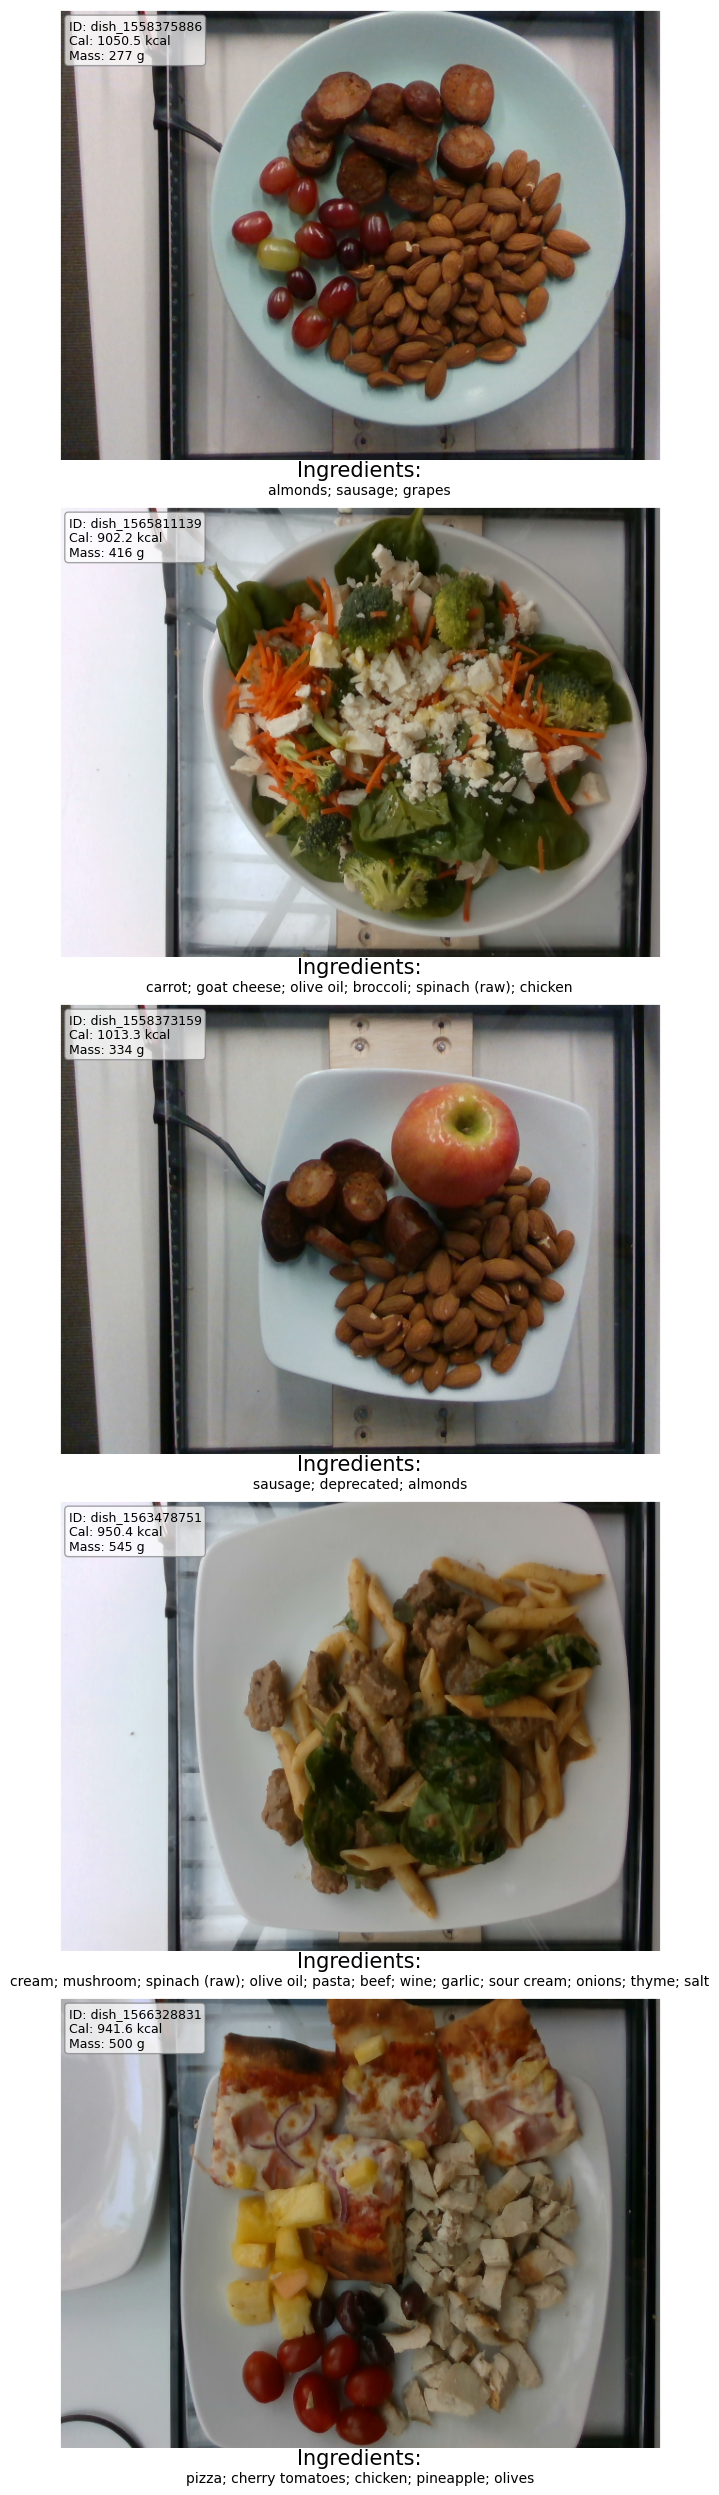

In [3]:
import torch
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import r2_score
import numpy as np

from DeepPlate import (
    Config, 
    MultimodalDataset, 
    multimodal_collate_fn, 
    get_multimodal_transforms)
from DeepPlate.src.cross_attention_model import CalorieRegressionModel

# ----------------------------
# 1. Загрузка конфигурации и модели
# ----------------------------
config = Config()

best_model_path: str = "models/best_model_(53.43)_b56.pth"
# Создаём модель и загружаем веса
model = CalorieRegressionModel(config)
model.load_state_dict(torch.load(best_model_path, weights_only=True))
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Модель загружена и перемещена на {device}")

# ----------------------------
# 2. Загрузка тестового датасета
# ----------------------------
test_transforms = get_multimodal_transforms(config, "test")
test_dataset = MultimodalDataset(config, split="test", transform=test_transforms)
# Получаем статистики массы из трейна (для корректной нормализации)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    collate_fn=multimodal_collate_fn,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

# ----------------------------
# 3. Инференс и сбор предсказаний
# ----------------------------
all_preds = []
all_labels = []
all_dish_ids = []

with torch.no_grad():
    for batch in test_loader:
        image = batch["image"].to(device, non_blocking=True)
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        mass = batch["mass"].to(device, non_blocking=True)
        labels = batch["label"]
        dish_ids = batch["dish_ids"]

        preds = model(image=image, input_ids=input_ids, attention_mask=attention_mask, mass=mass)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_dish_ids.extend(dish_ids)

# ----------------------------
# 4. Оценка качества
# ----------------------------
mae = np.mean(np.abs(np.array(all_preds) - np.array(all_labels)))
r2 = r2_score(all_labels, all_preds)

print(f" Финальная метрика на test:")
print(f"   MAE: {mae:.2f}")
print(f"   R²:  {r2:.4f}")

# ----------------------------
# 5. Топ-5 худших примеров
# ----------------------------
errors = np.abs(np.array(all_preds) - np.array(all_labels))
top5_idx = np.argsort(errors)[-5:][::-1]  # индексы 5 наибольших ошибок

print(f"\n Топ-5 блюд с наибольшей ошибкой предсказания:")
for i, idx in enumerate(top5_idx, 1):
    dish_id = all_dish_ids[idx]
    true_cal = all_labels[idx]
    pred_cal = all_preds[idx]
    error = errors[idx]
    print(f"{i}. dish_id={dish_id} | Истинно: {true_cal:.1f} | Предсказано: {pred_cal:.1f} | Ошибка: {error:.1f} ккал")

# Визуализация
test_dataset.show_samples(top5_idx.tolist(), figsize_per_sample=(8, 5))

Финальные выводы:

Судя по визуализации можно заметить некоторые странности, которые могли повлиять на качество оценки:

- Необычные ингредиенты
    - В тексте упомянуты редкие или неоднозначные продукты:
        -  (dish_id=dish_1558373159 | Истинно: 1013.3 | Предсказано: 586.6 | Ошибка: 426.7 ккал изображено яблоко, однако в ингридиентах оно не указано). 
        - В первом и последнем примерах изображена странная смесь продуктов, которая возможно не выступает как блюдо. Следует проанализировать характер именно блюд. Возможно большая часть выборки - это некоторые блюда, имеющие некоторые общие паттерны по сочетаемости продуктов, а данные продукты не попадает в эти паттерны. Исключение подобных продуктов может повысить качество.
    
- Выбросы в разметке (метках)
    -  Например, блюдо 1, которое весит 300 грамм и состоит из виноградин, горстки орехов и нарезанной колбаски 1050 ккал (должно быть ~300–450). Поэтому уместно предобработать данные лучше, принять решения по всем данным, величина калорий которых выше 800 ккал. Это может увеличить точность модели.

- Контекстуальная неоднозначность в написании ингредиентов может сказаться на точности.
    
    - Например, "салат" может быть овощным (низкокалорийным) или с майонезом и авокадо (высококалорийным). Без явного указания — модель гадает.
    Аномальная масса
    
    - Очень маленькие порции (<50 г) или очень большие (>1000 г) могут лежать за пределами обучающего распределения. Следует дополнительно рассмотреть возможность обработать данные выбросов индивидуальным способом, применить подстановку значений, операясь на IQR.

- Лучше поработать с аугментациями.
    
    - В процессе обучения возникло предположение, что настроена немного агрессивная аугментация и её можно пересмотреть на более частых семплах. 